<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/05_baseline_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os

# Creating the src folder and evaluation.py:
os.makedirs('src', exist_ok=True)

with open('src/evaluation.py', 'w') as f:
    f.write('''
import numpy as np

def calculate_rmse(predictions, actuals):
    return np.sqrt(np.mean((np.array(predictions) - np.array(actuals)) ** 2))

def calculate_mae(predictions, actuals):
    return np.mean(np.abs(np.array(predictions) - np.array(actuals)))

def precision_at_k(recommendations, relevant_items, k):
    if k == 0:
        return 0
    top_k = recommendations[:k]
    relevant_count = sum(1 for item in top_k if item in relevant_items)
    return relevant_count / k

def recall_at_k(recommendations, relevant_items, k):
    if len(relevant_items) == 0:
        return 0
    top_k = recommendations[:k]
    relevant_count = sum(1 for item in top_k if item in relevant_items)
    return relevant_count / len(relevant_items)

def f1_at_k(recommendations, relevant_items, k):
    p = precision_at_k(recommendations, relevant_items, k)
    r = recall_at_k(recommendations, relevant_items, k)
    if p + r == 0:
        return 0
    return 2 * (p * r) / (p + r)

def ndcg_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    dcg = 0
    for i, item in enumerate(top_k):
        if item in relevant_items:
            dcg += 1 / np.log2(i + 2)
    ideal_count = min(len(relevant_items), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_count))
    if idcg == 0:
        return 0
    return dcg / idcg

def hit_rate_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    return 1 if any(item in relevant_items for item in top_k) else 0

def mrr_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    for i, item in enumerate(top_k):
        if item in relevant_items:
            return 1 / (i + 1)
    return 0

def calculate_coverage(recommendations_list, total_items):
    all_recommended = set()
    for recs in recommendations_list:
        all_recommended.update(recs)
    return len(all_recommended) / total_items

def calculate_genre_diversity(recommended_items, movies_df):
    genres = set()
    for movie_id in recommended_items:
        movie_genres = movies_df[movies_df['movieId'] == movie_id]['genres'].values
        if len(movie_genres) > 0:
            for genre in movie_genres[0].split('|'):
                genres.add(genre)
    return len(genres)

def evaluate_model(model, test_data, movies_df, get_recommendations_func, k_values=[5, 10, 15, 20]):
    results = {}
    relevant_items_dict = {}
    for user_id in test_data['userId'].unique():
        user_data = test_data[test_data['userId'] == user_id]
        relevant = user_data[user_data['rating'] >= 4]['movieId'].tolist()
        relevant_items_dict[user_id] = relevant

    for k in k_values:
        all_precision = []
        all_recall = []
        all_f1 = []
        all_ndcg = []
        all_hit_rate = []
        all_mrr = []
        all_recommendations = []

        for user_id in test_data['userId'].unique():
            relevant = relevant_items_dict[user_id]
            if len(relevant) == 0:
                continue
            recs = get_recommendations_func(model, user_id, k)
            rec_ids = [r[0] for r in recs]
            all_recommendations.append(rec_ids)
            all_precision.append(precision_at_k(rec_ids, relevant, k))
            all_recall.append(recall_at_k(rec_ids, relevant, k))
            all_f1.append(f1_at_k(rec_ids, relevant, k))
            all_ndcg.append(ndcg_at_k(rec_ids, relevant, k))
            all_hit_rate.append(hit_rate_at_k(rec_ids, relevant, k))
            all_mrr.append(mrr_at_k(rec_ids, relevant, k))

        results[f'precision@{k}'] = np.mean(all_precision)
        results[f'recall@{k}'] = np.mean(all_recall)
        results[f'f1@{k}'] = np.mean(all_f1)
        results[f'ndcg@{k}'] = np.mean(all_ndcg)
        results[f'hit_rate@{k}'] = np.mean(all_hit_rate)
        results[f'mrr@{k}'] = np.mean(all_mrr)

    coverage = calculate_coverage(all_recommendations, len(movies_df))
    results['coverage'] = coverage
    return results
''')

print("src/evaluation.py created successfully!")

src/evaluation.py created successfully!


Loading MovieLens dataset...
Data loaded from local files
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610

POPULARITY RECOMMENDER TRAINED
Movies with >= 10 votes: 2,269

EVALUATING POPULARITY RECOMMENDER
Test users: 50

POPULARITY BASELINE RESULTS
precision@5: 0.5292
recall@5: 0.0187
f1@5: 0.0348
ndcg@5: 0.5343
hit_rate@5: 0.8542
mrr@5: 0.6830
precision@10: 0.4979
recall@10: 0.0345
f1@10: 0.0606
ndcg@10: 0.5106
hit_rate@10: 0.9167
mrr@10: 0.6922
precision@15: 0.4653
recall@15: 0.0481
f1@15: 0.0804
ndcg@15: 0.4860
hit_rate@15: 0.9167
mrr@15: 0.6922
precision@20: 0.4448
recall@20: 0.0620
f1@20: 0.0983
ndcg@20: 0.4688
hit_rate@20: 0.9375
mrr@20: 0.6935
coverage: 0.0021


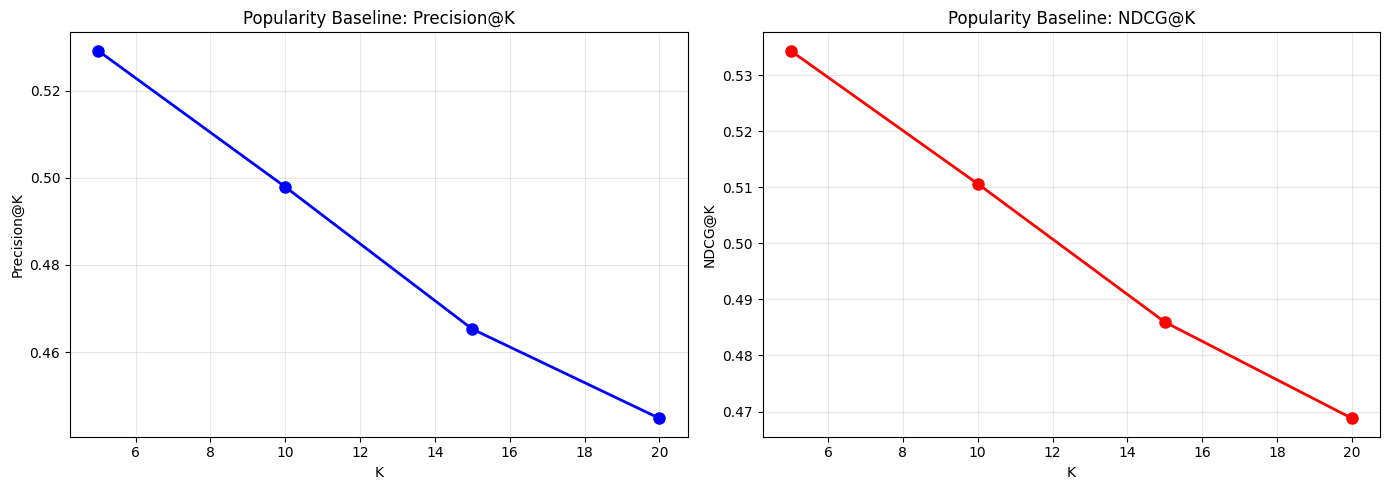

Popularity baseline evaluation complete!
Best Precision@10: 0.4979
Best NDCG@10: 0.5106
Coverage: 0.21%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO 3: EVALUATE POPULARITY BASELINE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO

print("Loading MovieLens dataset...")

# Try to load from local files first
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")

except FileNotFoundError:
    # Download if files don't exist
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))

    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))

    # Save for future runs
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")

# Merging the datasets:
df = pd.merge(ratings_df, movies_df, on='movieId')

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

# 2. POPULARITY RECOMMENDER
class PopularityRecommender:
    def __init__(self, min_votes=5):
        self.min_votes = min_votes
        self.popularity_scores = None

    def fit(self, df):
        # Grouping by movie:
        movie_stats = df.groupby('movieId').agg({
            'rating': ['mean', 'count']
        }).reset_index()
        movie_stats.columns = ['movieId', 'avg_rating', 'vote_count']

        # Filtering by minimum votes:
        movie_stats = movie_stats[movie_stats['vote_count'] >= self.min_votes]

        # Calculating the popularity score (weighted by vote count):
        movie_stats['popularity'] = movie_stats['avg_rating'] * np.log(movie_stats['vote_count'] + 1)
        movie_stats = movie_stats.sort_values('popularity', ascending=False)

        self.popularity_scores = movie_stats
        return self

    def recommend(self, user_id, n=10):
        """Return top N popular movies."""
        top_movies = self.popularity_scores.head(n)[['movieId', 'popularity']]
        return list(zip(top_movies['movieId'].tolist(), top_movies['popularity'].tolist()))

# Trainning the model:
pop_model = PopularityRecommender(min_votes=10)
pop_model.fit(df)

print("\n" + "=" * 60)
print("POPULARITY RECOMMENDER TRAINED")
print("=" * 60)
print(f"Movies with >= 10 votes: {len(pop_model.popularity_scores):,}")

# 3. Evaluating the popularity recommender
# Import evaluation functions
import sys
sys.path.append('..')
from src.evaluation import evaluate_model

# Function to get recommendations (required by evaluate_model):
def get_popularity_recommendations(model, user_id, k):
    """Wrapper for popularity model's recommend method."""
    return model.recommend(user_id, k)

# Creating the test data (sample of users):
test_users = df['userId'].sample(50, random_state=42)
test_data = df[df['userId'].isin(test_users)]

print("\n" + "=" * 60)
print("EVALUATING POPULARITY RECOMMENDER")
print("=" * 60)
print(f"Test users: {len(test_users)}")

# Evaluating:
k_values = [5, 10, 15, 20]
results = evaluate_model(
    model=pop_model,
    test_data=test_data,
    movies_df=movies_df,
    get_recommendations_func=get_popularity_recommendations,
    k_values=k_values
)

# 4. Displaying the results:
print("\n" + "=" * 60)
print("POPULARITY BASELINE RESULTS")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value:.4f}")


# 5. Visualizing the results:
# Extraction precision values for different K:
k_values = [5, 10, 15, 20]
precision_values = [results[f'precision@{k}'] for k in k_values]
ndcg_values = [results[f'ndcg@{k}'] for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision@K
axes[0].plot(k_values, precision_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].set_title('Popularity Baseline: Precision@K')
axes[0].grid(True, alpha=0.3)

# NDCG@K
axes[1].plot(k_values, ndcg_values, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('NDCG@K')
axes[1].set_title('Popularity Baseline: NDCG@K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('popularity_baseline_results.png')
plt.show()

print("Popularity baseline evaluation complete!")
print(f"Best Precision@10: {results['precision@10']:.4f}")
print(f"Best NDCG@10: {results['ndcg@10']:.4f}")
print(f"Coverage: {results['coverage']:.2%}")